In [1]:
# Core utilities
import os
import random
import h5py

import numpy as np
import pandas as pd

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

# Visualization
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import plotly.graph_objects as go

# Optional hardware-aware seed setup (kept from prior workflow)
import torch

# ---------------------------------------------------------------------
# Global configuration
# ---------------------------------------------------------------------
SEED = 1998
RANDOM_STATE = 42
TEST_SIZE = 0.1
BOOTSTRAP_ITERS = 1000
TOP_K = 10

DATA_DISASTER_PATH = "../src/data/processed/disaster.h5"
DATA_IDU_PATH = "../src/data/processed/testing.h5"
EMBEDDINGS_PATH = "../src/data/processed/embeddings_mapped.csv"

# ---------------------------------------------------------------------
# Shared plotting style
# ---------------------------------------------------------------------
FONT_FAMILY = "Helvetica Neue, Helvetica, Arial, DejaVu Sans"
TEXT_DARK = "#1a1a1a"
AXIS_GREY = "#aaaaaa"
GRID_RGBA = "rgba(0,0,0,0.09)"
MODEL_A_COLOR = "#4C72B0"
MODEL_B_COLOR = "#55A868"
ACCENT_RED = "#C44E52"

def apply_plotly_style(fig, title, height=460, width=900, margin=None):
    """Apply one consistent Plotly theme across all interactive/static figures."""
    if margin is None:
        margin = dict(l=20, r=20, t=64, b=50)
    fig.update_layout(
        template="simple_white",
        height=height,
        width=width,
        margin=margin,
        font=dict(family=FONT_FAMILY, size=11, color=TEXT_DARK),
        title=dict(
            text=f"<b>{title}</b>",
            x=0.01,
            xanchor="left",
            font=dict(size=15),
        ),
    )
    return fig

def style_matplotlib_axes(ax, title=None, xlabel=None, ylabel=None, grid_axis="both"):
    """Apply one consistent matplotlib axis style."""
    if title is not None:
        ax.set_title(title, fontsize=12, fontweight="bold", loc="left", pad=9, color="#111111")
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=9.5, fontweight="bold", labelpad=6)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=9.5, fontweight="bold", labelpad=6)

    ax.spines["left"].set_color(AXIS_GREY)
    ax.spines["bottom"].set_color(AXIS_GREY)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.tick_params(axis="both", which="major", labelsize=8.5, length=3, color="#555")
    ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.6, alpha=0.25)
    ax.set_axisbelow(True)

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Plot defaults
sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

Device: mps


In [2]:
# ---------------------------------------------------------------------
# Data loading module
# ---------------------------------------------------------------------
def ensure_output_dirs(base_dir="models"):
    os.makedirs(base_dir, exist_ok=True)
    os.makedirs(os.path.join(base_dir, "checkpoints"), exist_ok=True)
    return base_dir

def read_hdf5_to_dataframe_with_index(h5_path):
    """Read HDF5 tensors and metadata into a row-wise DataFrame indexed by `indices`."""
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        disaster_type = f["type"][:]

    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    type_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in disaster_type]

    df_out = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": type_decoded,
        },
        index=indices,
    )
    return df_out.sort_index()

def load_training_data(disaster_path=DATA_DISASTER_PATH, idu_path=DATA_IDU_PATH, embeddings_path=EMBEDDINGS_PATH):
    """Load and merge disaster + IDU records, plus country embeddings."""
    df_disaster = read_hdf5_to_dataframe_with_index(disaster_path)
    df_idu = read_hdf5_to_dataframe_with_index(idu_path)
    embeddings = pd.read_csv(embeddings_path, index_col=0)

    df_all = pd.concat([df_disaster, df_idu], ignore_index=True)
    return df_all, embeddings

folder_path = ensure_output_dirs("models")
df, iso3_embeddings = load_training_data()
print(f"Loaded rows: {len(df):,}")
print(f"Embedding shape: {iso3_embeddings.shape}")

Loaded rows: 16,896
Embedding shape: (232, 4)


# XGBoost Regression Pipeline
This notebook is organized into reusable modules:
1. setup and data loading
2. feature engineering
3. training and evaluation
4. diagnostics and publication-ready figures

## Model Definitions
- **Model A**: country embeddings + disaster type
- **Model B**: full feature suite (Model A + image summary features)
- Target is modeled as `log1p(figures)` for stability

In [3]:
# ---------------------------------------------------------------------
# Feature engineering + training/evaluation module
# ---------------------------------------------------------------------
def get_image_stats(image_array):
    """Extract 8 summary statistics from an image tensor/array."""
    if image_array is None:
        return np.zeros(8, dtype=float)
    img = np.asarray(image_array)
    if img.size == 0:
        return np.zeros(8, dtype=float)
    flat = img.ravel()
    return np.array([
        np.mean(flat),
        np.std(flat),
        np.min(flat),
        np.max(flat),
        np.percentile(flat, 25),
        np.percentile(flat, 50),
        np.percentile(flat, 75),
        np.ptp(flat),
    ], dtype=float)

def process_image_columns(df_in, columns_map):
    """Build per-image summary feature tables and concatenate them."""
    blocks = []
    for col, prefix in columns_map.items():
        stats = df_in[col].apply(get_image_stats)
        block = pd.DataFrame(
            np.vstack(stats.values),
            columns=[f"{prefix}_{i}" for i in range(8)],
            index=df_in.index,
        )
        blocks.append(block)
    return pd.concat(blocks, axis=1)

def prepare_features(df_in, embeddings_df):
    """Prepare X/y and feature subsets for Model A and Model B."""
    embedding_df = embeddings_df.reset_index().rename(
        columns={embeddings_df.index.name or "index": "iso3"}
    )
    merged = df_in.merge(embedding_df, on="iso3", how="inner")
    merged["type"] = merged["type"].astype("category")

    image_map = {"viirs_start": "vs", "viirs_end": "ve", "rgb": "rgb"}
    image_features = process_image_columns(merged, image_map)

    embed_cols = [c for c in embedding_df.columns if c != "iso3"]
    features_a = embed_cols + ["type"]

    x_full = pd.concat([merged[["iso3", "type"]], merged[embed_cols], image_features], axis=1)
    x_full = x_full.loc[:, ~x_full.columns.duplicated()]

    y_raw = merged["figures"].to_numpy(np.float32)
    y_log = np.log1p(y_raw)
    return x_full, y_log, features_a

def build_xgb_regressor(random_state=RANDOM_STATE):
    """XGBoost regressor configured for tabular mixed feature types."""
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=random_state,
        n_jobs=-1,
        early_stopping_rounds=100,
        enable_categorical=True,
        tree_method="hist",
    )

def bootstrap_metrics(y_true, y_pred, n_iterations=BOOTSTRAP_ITERS, random_state=RANDOM_STATE):
    """Estimate R2/MAE/RMSE distributions via bootstrap resampling."""
    stats = {"R2": [], "MAE": [], "RMSE": []}
    rng = np.random.default_rng(random_state)
    for _ in range(n_iterations):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        stats["R2"].append(r2_score(yt, yp))
        stats["MAE"].append(mean_absolute_error(yt, yp))
        stats["RMSE"].append(np.sqrt(mean_squared_error(yt, yp)))
    return pd.DataFrame(stats)

def format_feature_labels(feature_names):
    stat_map = {0: "mean", 1: "std", 2: "min", 3: "max", 4: "25th", 5: "50th", 6: "75th", 7: "ptp"}
    prefix_map = {"vs": "VIIRS Start", "ve": "VIIRS End", "rgb": "RGB"}
    labels = []
    for feat in feature_names:
        if feat == "type":
            labels.append("Category (Type)")
        elif any(feat.startswith(p) for p in ["vs_", "ve_", "rgb_"]):
            prefix, idx = feat.split("_")
            labels.append(f"{prefix_map[prefix]} {stat_map[int(idx)]}")
        else:
            labels.append(f"Embed: {feat}")
    return labels

def export_performance_pdf(y_test, pred_dict, boot_dict, imp_df, output_path="Model_Performance_Analysis.pdf"):
    """Generate a compact 4-panel report figure and export as PDF."""
    fig = plt.figure(figsize=(16, 5), dpi=300)
    gs = GridSpec(1, 4, width_ratios=[1, 1, 0.8, 0.9])
    colors = [MODEL_A_COLOR, MODEL_B_COLOR]

    for i, (name, y_pred) in enumerate(pred_dict.items()):
        ax = fig.add_subplot(gs[0, i])
        ax.scatter(y_test, y_pred, s=20, alpha=0.4, color=colors[i], edgecolors="none")
        ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--", lw=1, color="#444444")
        style_matplotlib_axes(
            ax,
            title=name,
            xlabel="Observed (log)",
            ylabel="Predicted (log)",
            grid_axis="both",
        )

    ax_boot = fig.add_subplot(gs[0, 2])
    violin = ax_boot.violinplot([boot_dict["A"]["R2"], boot_dict["B"]["R2"]], showmedians=True)
    for i, body in enumerate(violin["bodies"]):
        body.set_facecolor(colors[i])
        body.set_edgecolor("black")
        body.set_alpha(0.6)
    ax_boot.set_xticks([1, 2])
    ax_boot.set_xticklabels(["Model A", "Model B"])
    style_matplotlib_axes(ax_boot, title="Statistical Stability ($R^2$)", grid_axis="y")

    ax_imp = fig.add_subplot(gs[0, 3])
    top_imp = imp_df.head(12).iloc[::-1]
    ax_imp.barh(
        top_imp["display_name"],
        top_imp["importance_mean"],
        xerr=top_imp["importance_std"],
        color=ACCENT_RED,
        alpha=0.8,
    )
    style_matplotlib_axes(
        ax_imp,
        title="Feature Importance (Model B)",
        xlabel="Drop in $R^2$",
        ylabel="",
        grid_axis="x",
    )

    plt.tight_layout()
    plt.savefig(output_path, format="pdf", bbox_inches="tight")
    print(f"Saved report: {output_path}")

def safe_r2(g, truth_col, pred_col):
    return r2_score(g[truth_col], g[pred_col]) if len(g) > 1 else np.nan

def run_experiment(df_in, embeddings_df, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Run complete train/eval workflow and return all artifacts."""
    x_full, y_log, features_a = prepare_features(df_in, embeddings_df)
    features_b = [c for c in x_full.columns if c != "iso3"]

    x_train, x_test, y_train, y_test = train_test_split(
        x_full, y_log, test_size=test_size, random_state=random_state
    )

    model_a = build_xgb_regressor(random_state=random_state)
    model_a.fit(
        x_train[features_a],
        y_train,
        eval_set=[(x_test[features_a], y_test)],
        verbose=False,
    )

    model_b = build_xgb_regressor(random_state=random_state)
    model_b.fit(
        x_train[features_b],
        y_train,
        eval_set=[(x_test[features_b], y_test)],
        verbose=False,
    )

    preds_a = model_a.predict(x_test[features_a])
    preds_b = model_b.predict(x_test[features_b])

    boot_a = bootstrap_metrics(y_test, preds_a)
    boot_b = bootstrap_metrics(y_test, preds_b)

    importance = permutation_importance(
        model_b,
        x_test[features_b],
        y_test,
        n_repeats=10,
        random_state=random_state,
    )
    imp_df = pd.DataFrame({
        "feature": features_b,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }).sort_values("importance_mean", ascending=False)
    imp_df["display_name"] = format_feature_labels(imp_df["feature"])

    results_df = pd.DataFrame({
        "iso3": x_test["iso3"].values,
        "type": x_test["type"].values,
        "y_true": y_test,
        "y_pred_A": preds_a,
        "y_pred_B": preds_b,
    })

    r2_by_country = (
        results_df.groupby("iso3", observed=True)
        .apply(lambda g: safe_r2(g, "y_true", "y_pred_B"))
        .dropna()
        .sort_values(ascending=False)
    )
    r2_by_type = (
        results_df.groupby("type", observed=True)
        .apply(lambda g: safe_r2(g, "y_true", "y_pred_B"))
        .dropna()
        .sort_values(ascending=False)
    )

    return {
        "x_full": x_full,
        "x_test": x_test,
        "y_test": y_test,
        "features_a": features_a,
        "features_b": features_b,
        "model_a": model_a,
        "model_b": model_b,
        "preds_a": preds_a,
        "preds_b": preds_b,
        "boot_a": boot_a,
        "boot_b": boot_b,
        "importance_df": imp_df,
        "results_df": results_df,
        "r2_by_country": r2_by_country,
        "r2_by_type": r2_by_type,
    }

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_89220/3438771661.py:207: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df.groupby("iso3", observed=True)
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_89220/3438771661.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df.groupby("type", observed=True)
feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't kn

Saved report: Model_Performance_Analysis.pdf
Top 5 countries by Model B R2:
iso3
AFG    0.763534
SYR    0.709034
BGD    0.682347
CRI    0.569640
RUS    0.440067
dtype: float64

R2 by disaster type:
type
Mixed disasters        0.830661
Earthquake             0.477178
Erosion                0.465819
Flood                  0.426368
Storm                  0.407932
Volcanic activity      0.396757
Mass Movement          0.313547
Drought                0.281956
Wildfire               0.164032
Extreme Temperature   -3.024090
dtype: float64


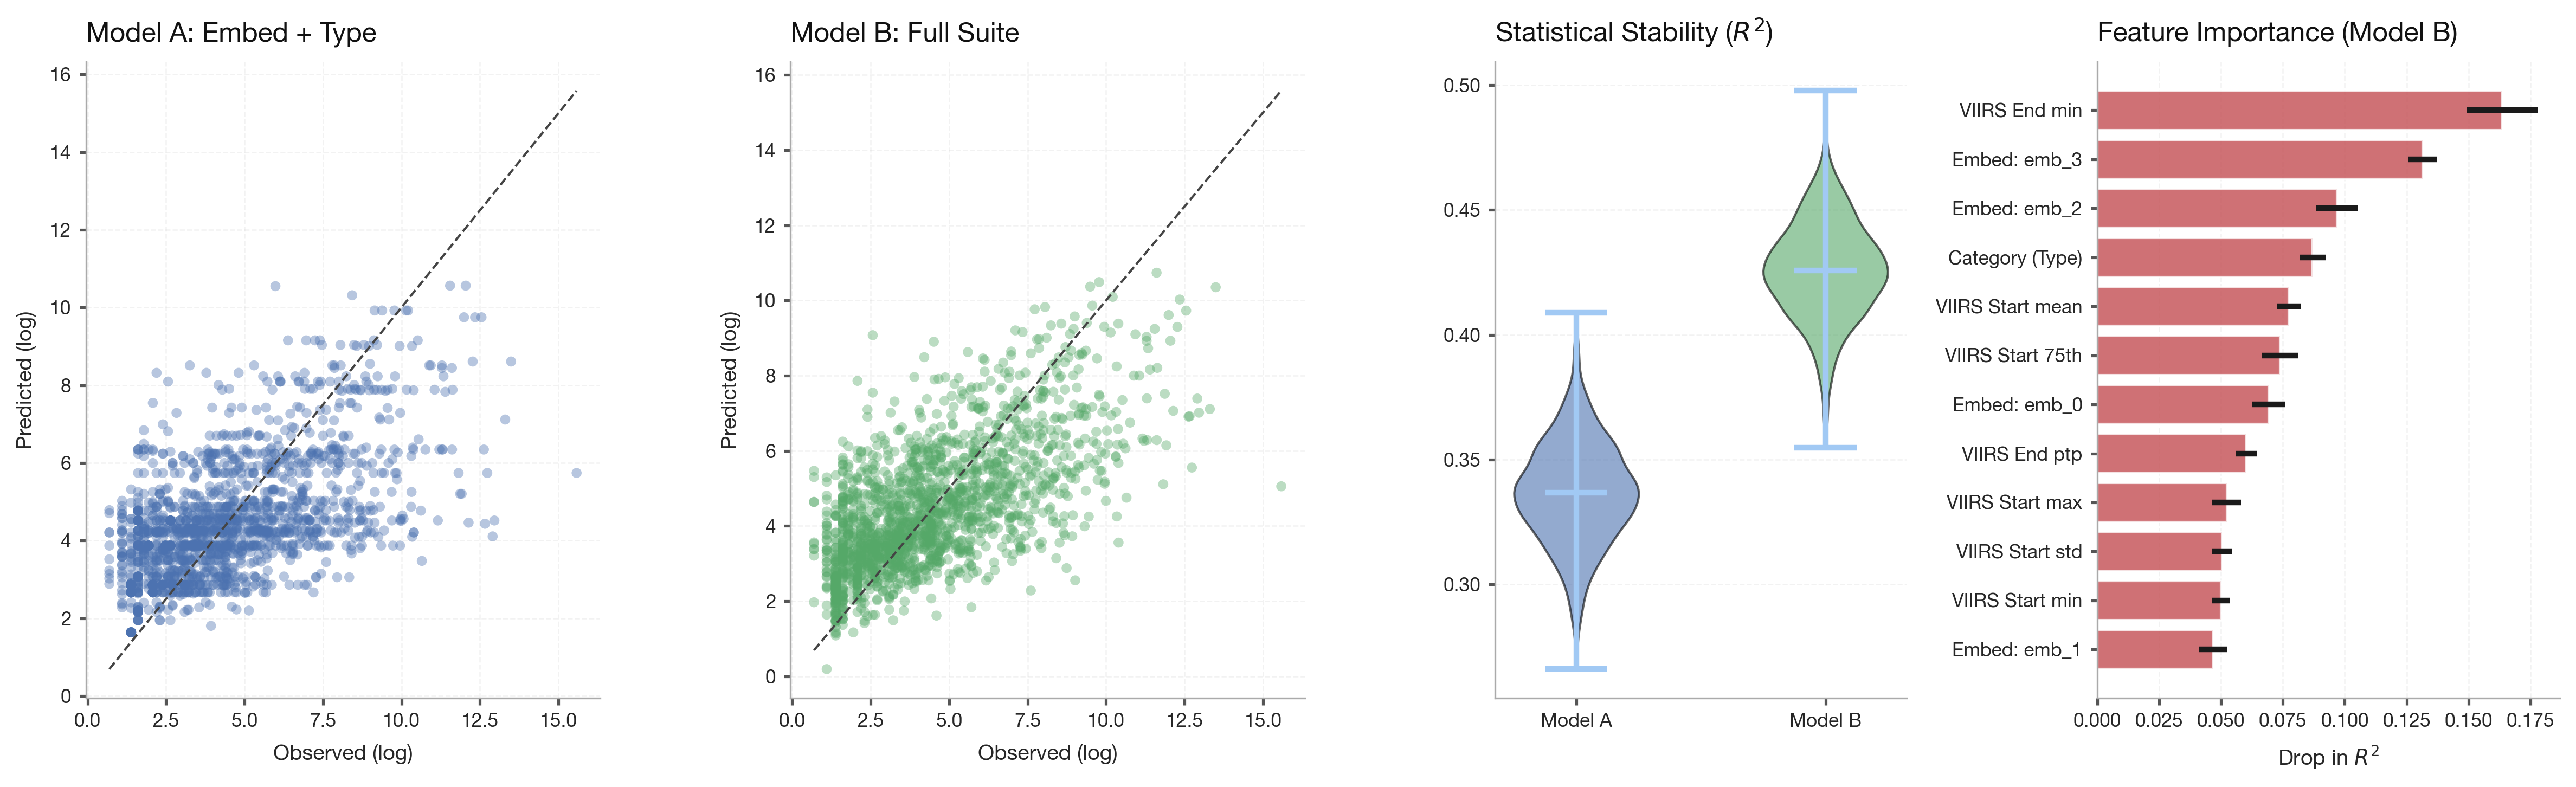

In [4]:
# ---------------------------------------------------------------------
# Execute experiment + core report outputs
# ---------------------------------------------------------------------
artifacts = run_experiment(df, iso3_embeddings)

# Expose frequently used outputs for downstream cells
y_test = artifacts["y_test"]
preds_a = artifacts["preds_a"]
preds_b = artifacts["preds_b"]
boot_a = artifacts["boot_a"]
boot_b = artifacts["boot_b"]
imp_df = artifacts["importance_df"]
results_df = artifacts["results_df"]
r2_by_country = artifacts["r2_by_country"]
r2_by_type = artifacts["r2_by_type"]

export_performance_pdf(
    y_test=y_test,
    pred_dict={
        "Model A: Embed + Type": preds_a,
        "Model B: Full Suite": preds_b,
    },
    boot_dict={"A": boot_a, "B": boot_b},
    imp_df=imp_df,
    output_path="Model_Performance_Analysis.pdf",
)

print("Top 5 countries by Model B R2:")
print(r2_by_country.head(5))
print("\nR2 by disaster type:")
print(r2_by_type)

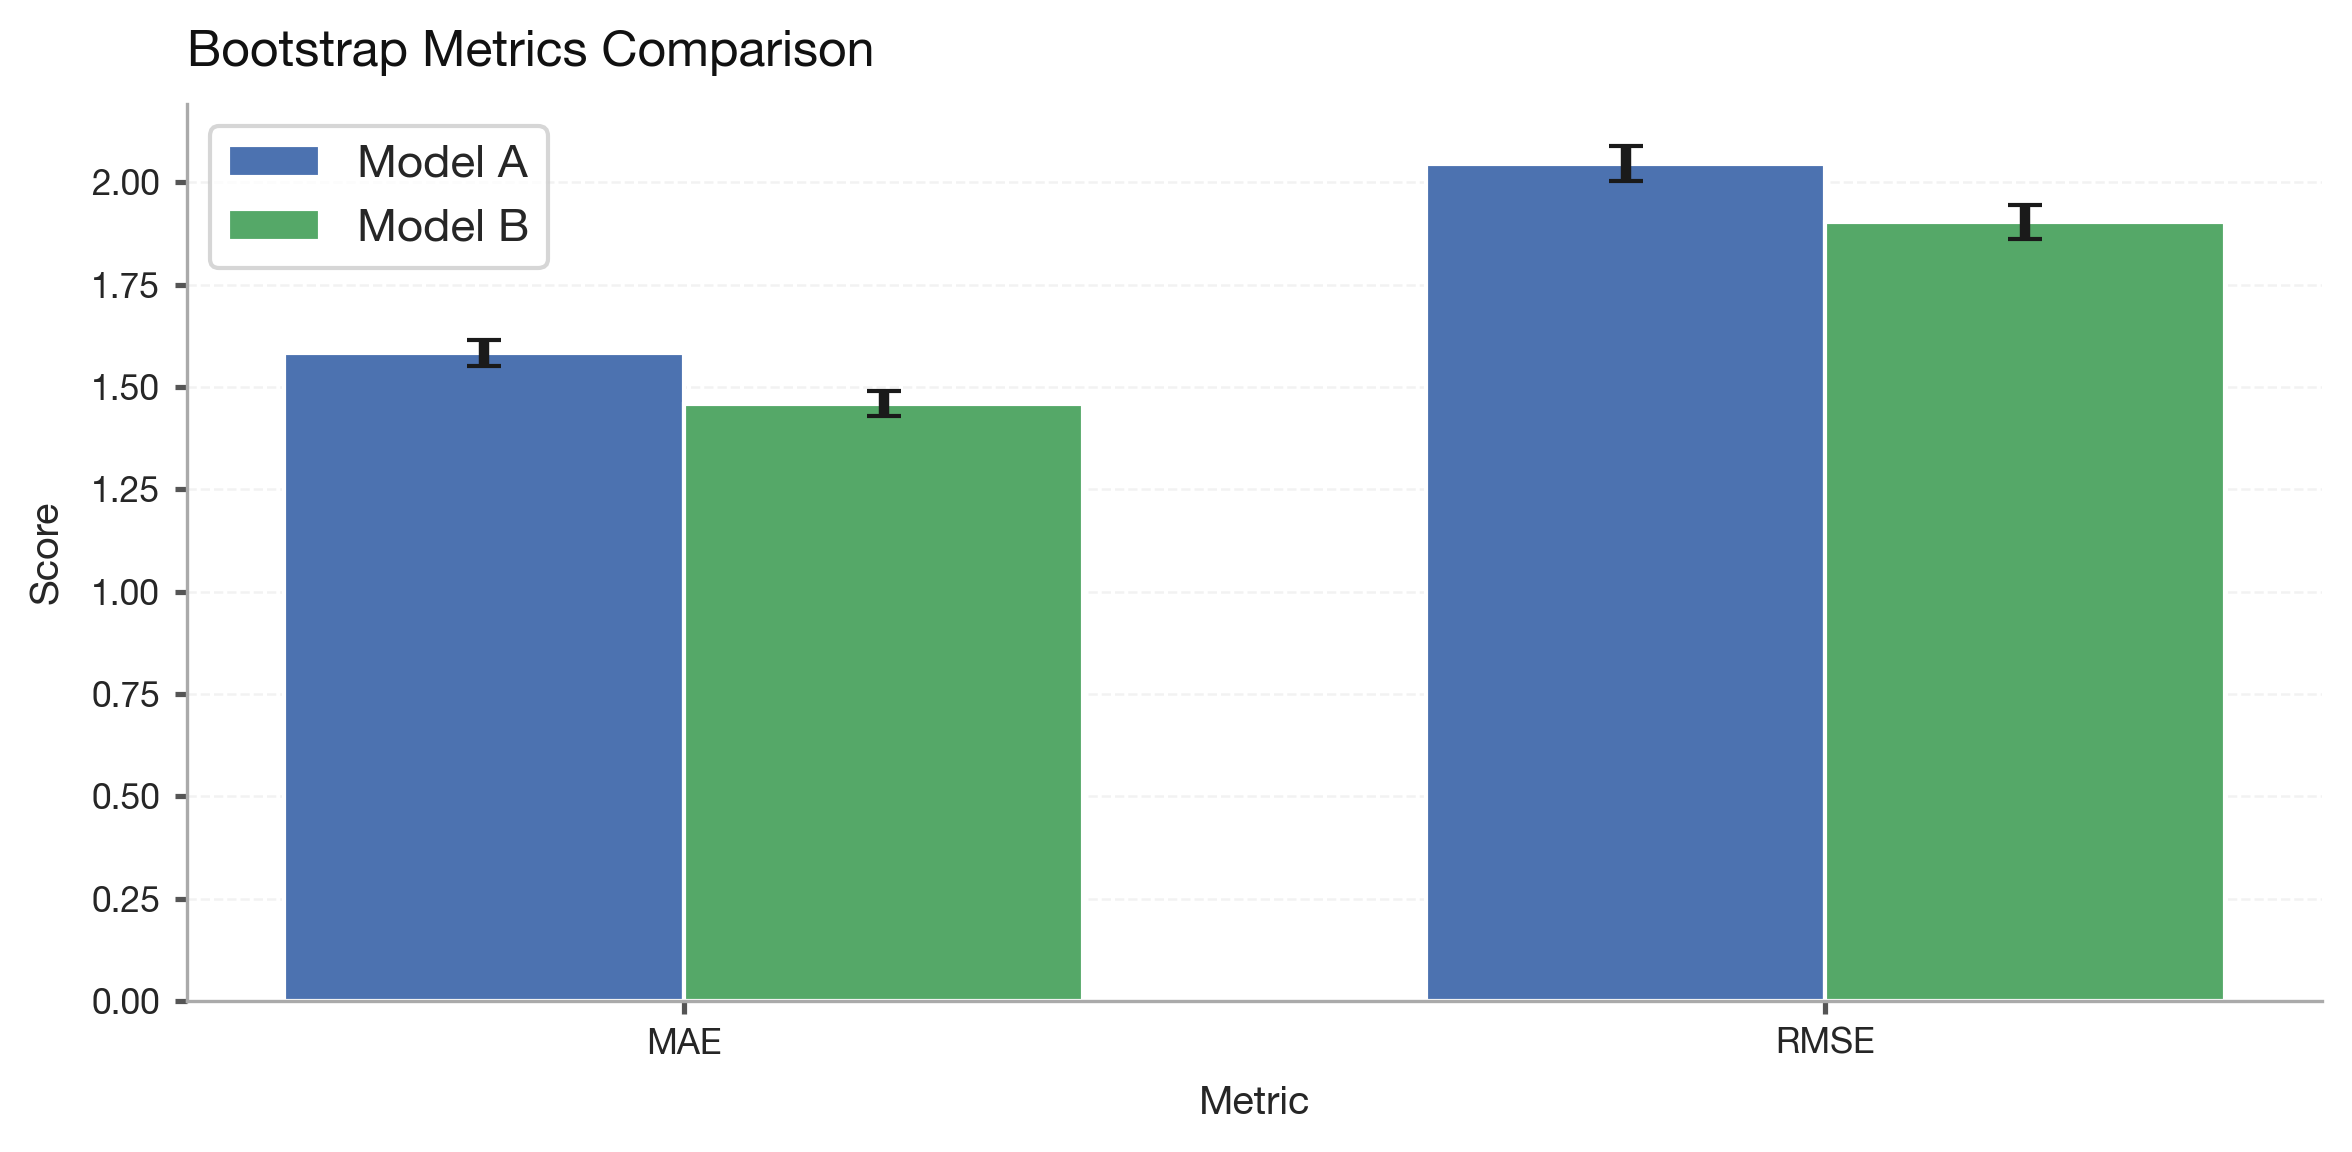

In [5]:
# ---------------------------------------------------------------------
# Bootstrap comparison chart
# ---------------------------------------------------------------------
def plot_bootstrap_metric_comparison(boot_a_df, boot_b_df):
    """Compare MAE and RMSE bootstrap means with uncertainty bars."""
    metrics = ["MAE", "RMSE"]
    means_a = [boot_a_df[m].mean() for m in metrics]
    std_a = [boot_a_df[m].std() for m in metrics]
    means_b = [boot_b_df[m].mean() for m in metrics]
    std_b = [boot_b_df[m].std() for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
    ax.bar(x - width / 2, means_a, width, yerr=std_a, capsize=4, label="Model A", color=MODEL_A_COLOR)
    ax.bar(x + width / 2, means_b, width, yerr=std_b, capsize=4, label="Model B", color=MODEL_B_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    style_matplotlib_axes(
        ax,
        title="Bootstrap Metrics Comparison",
        xlabel="Metric",
        ylabel="Score",
        grid_axis="y",
    )
    ax.legend(frameon=True, edgecolor="#cccccc")
    plt.tight_layout()
    plt.show()

plot_bootstrap_metric_comparison(boot_a, boot_b)

/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_89220/2369184928.py:55: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image(output_pdf, engine="kaleido")


Saved: Performance_Nature_Left_Aligned.pdf


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_89220/2369184928.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_df["R2"] = eval_df.groupby("iso3", observed=True).apply(safe_r2_local).values
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_89220/2369184928.py:151: DeprecationWarning: 
Support for the 'engine' argument is deprecated and will be removed after September 2025.
Kaleido will be the only supported engine at that time.

  fig.write_image(pdf_out, engine="kaleido")


feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


Saved: per_country_mae_map.html / per_country_mae_map.pdf


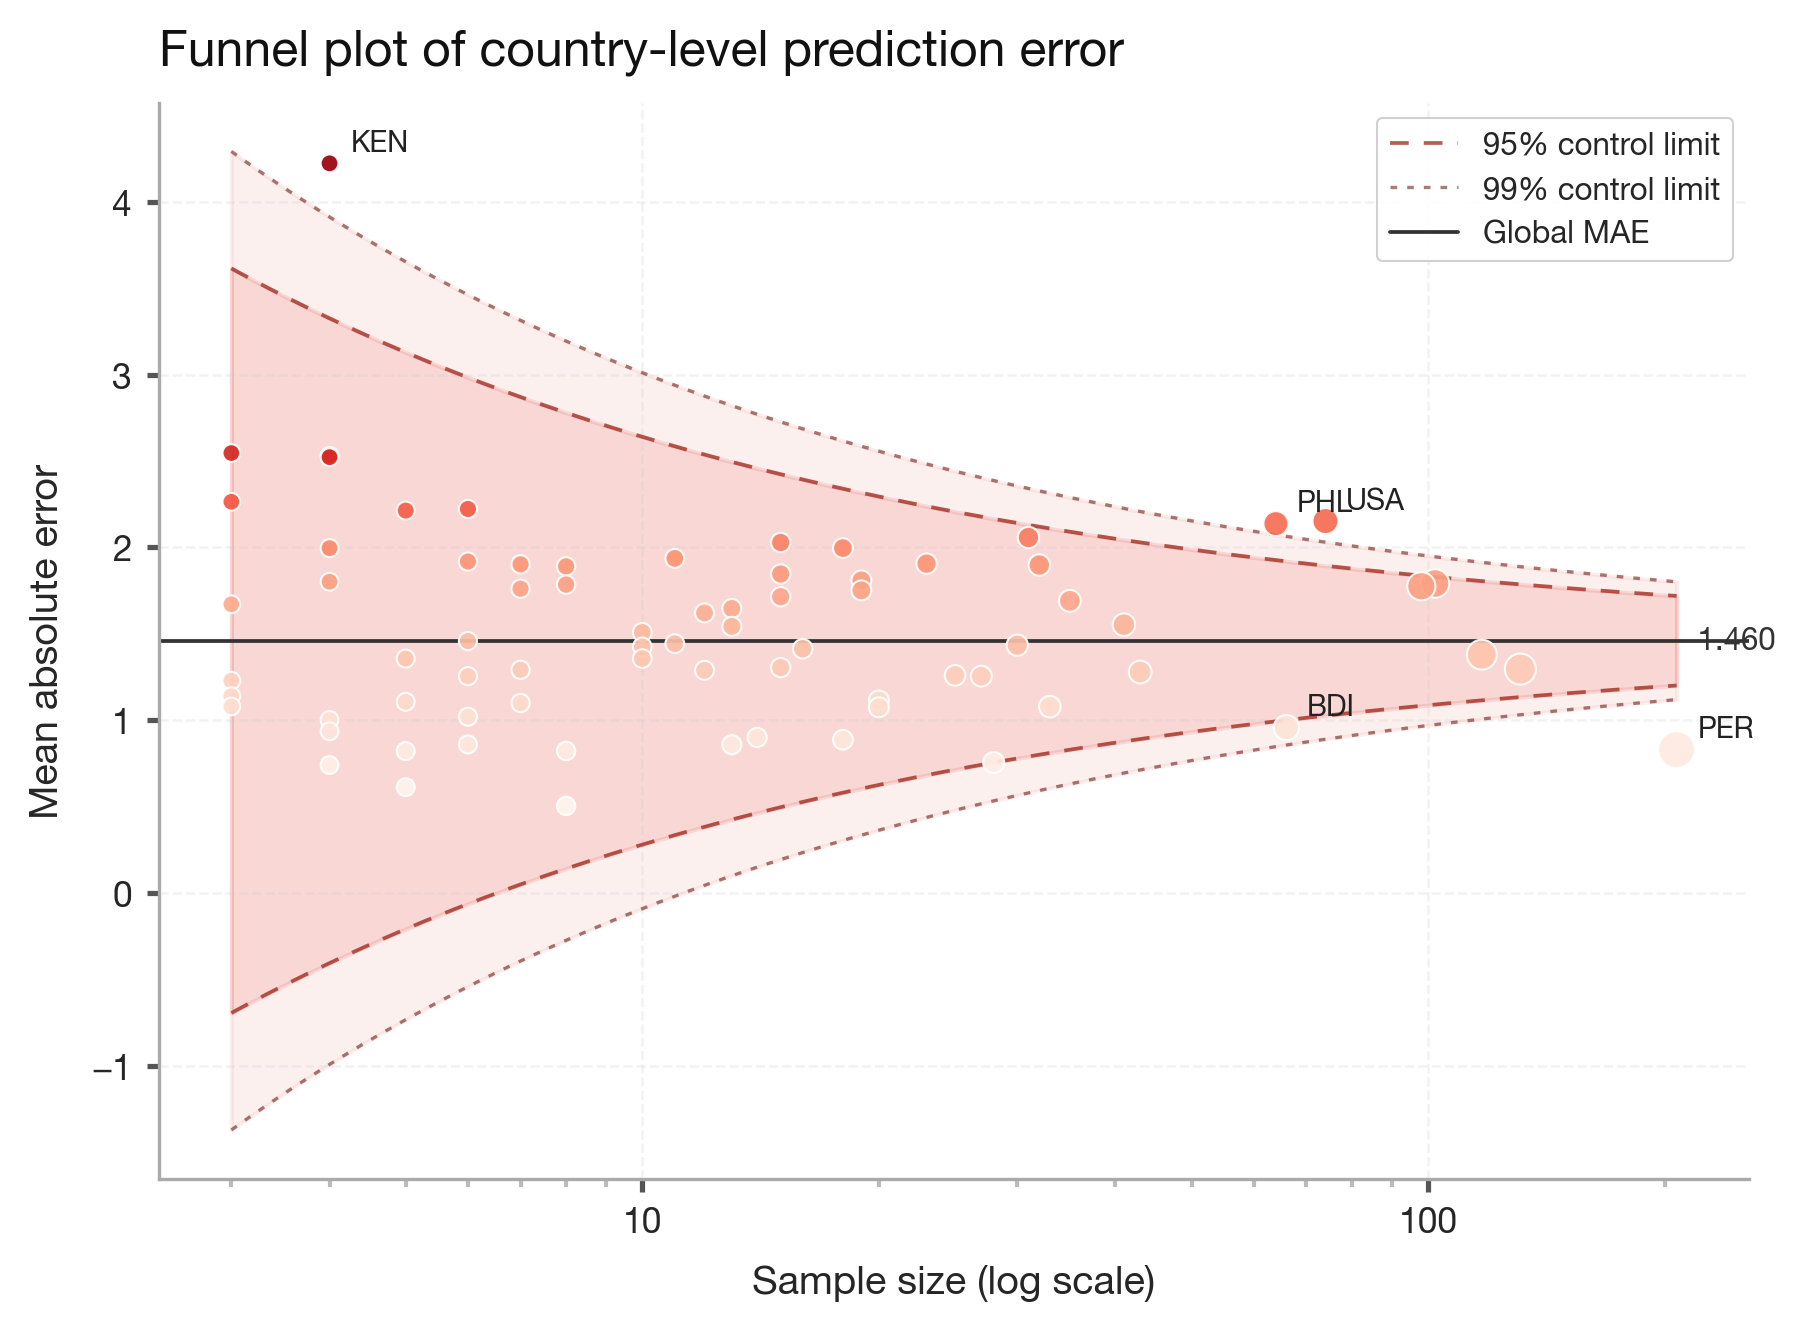

Saved: per_country_error_funnel.pdf / per_country_error_funnel.png
Saved: per_country_metrics.csv
Saved: worst_countries_table.csv
Worst-performing countries by MAE:
iso3  n      MAE     RMSE  MedianAE        R2
 TZA  1 4.503689 4.503689  4.503689       NaN
 KEN  4 4.223387 4.388403  3.846707 -4.274802
 POL  2 4.193867 4.526555  4.193867       NaN
 GUM  2 3.488769 3.518723  3.488769       NaN
 LBN  2 3.148915 3.274367  3.148915       NaN
 COM  2 3.144769 3.278079  3.144769       NaN
 MDA  1 2.735895 2.735895  2.735895       NaN
 MDG  3 2.546140 2.994094  3.012133 -1.548297
 HUN  2 2.537628 2.552438  2.537628       NaN
 GEO  4 2.530084 2.553225  2.709881 -1.897030


In [6]:
# ---------------------------------------------------------------------
# Post-model diagnostics: by-type performance + country diagnostics
# ---------------------------------------------------------------------
SUBTLE_GREY = "#737373"
NATURE_RED = mcolors.LinearSegmentedColormap.from_list(
    "nature_red",
    ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#ef3b2c", "#99000d"],
)
SPINE_COLOR = AXIS_GREY
GRID_COLOR = (0, 0, 0, 0.09)

def build_type_performance_df(r2_by_type_series, results_df_in):
    counts = results_df_in.groupby("type", observed=True).size().reset_index(name="count")
    return (
        r2_by_type_series.reset_index(name="r2")
        .merge(counts, on="type", how="left")
        .sort_values("r2")
    )

def plot_r2_by_type(df_type, output_pdf="Performance_Nature_Left_Aligned.pdf"):
    colors = df_type["r2"].apply(lambda x: "#252525" if x > 0 else "#cb181d")
    fig = go.Figure(
        go.Bar(
            y=df_type["type"],
            x=df_type["r2"],
            orientation="h",
            width=0.6,
            marker=dict(color=colors, line=dict(color="black", width=1)),
            text=[
                f"{r:.2f} <span style='color:{SUBTLE_GREY};'>(n={n})</span>"
                for r, n in zip(df_type["r2"], df_type["count"])
            ],
            textposition="outside",
            cliponaxis=False,
        )
    )

    apply_plotly_style(
        fig,
        title="Predictive Performance by Disaster Category",
        height=450,
        width=900,
        margin=dict(l=20, r=150, t=60, b=60),
    )
    fig.update_xaxes(
        title="R² Score",
        zeroline=True,
        zerolinewidth=1.5,
        zerolinecolor="black",
        showline=True,
        linecolor="black",
        gridcolor=GRID_RGBA,
    )
    fig.update_yaxes(title="", automargin=True)
    fig.write_image(output_pdf, engine="kaleido")
    fig.show()
    print(f"Saved: {output_pdf}")
    return fig

def compute_country_metrics(results_df_in):
    eval_df = results_df_in.assign(
        y_obs=results_df_in["y_true"],
        y_pred=results_df_in["y_pred_B"],
    ).copy()
    eval_df["residual"] = eval_df["y_obs"] - eval_df["y_pred"]
    eval_df["abs_error"] = eval_df["residual"].abs()
    eval_df["sq_error"] = eval_df["residual"] ** 2

    def safe_r2_local(g):
        yt, yp = g["y_obs"], g["y_pred"]
        return r2_score(yt, yp) if len(g) >= 3 and yt.nunique() > 1 else np.nan

    metrics_df = (
        eval_df.groupby("iso3", observed=True)
        .agg(
            n=("residual", "size"),
            MAE=("abs_error", "mean"),
            RMSE=("sq_error", lambda x: np.sqrt(x.mean())),
            MedianAE=("abs_error", "median"),
            MeanObs=("y_obs", "mean"),
            StdObs=("y_obs", "std"),
        )
        .reset_index()
    )
    metrics_df["R2"] = eval_df.groupby("iso3", observed=True).apply(safe_r2_local).values
    metrics_df = metrics_df.sort_values("MAE", ascending=False).reset_index(drop=True)
    return metrics_df, eval_df

def plot_country_mae_choropleth(metrics_df, html_out="per_country_mae_map.html", pdf_out="per_country_mae_map.pdf"):
    vmin = float(metrics_df["MAE"].quantile(0.05))
    vmax = float(metrics_df["MAE"].quantile(0.95))

    plotly_scale = [[t, mcolors.to_hex(NATURE_RED(t))] for t in np.linspace(0, 1, 12)]
    fig = go.Figure(go.Choropleth(
        locations=metrics_df["iso3"],
        z=metrics_df["MAE"],
        zmin=vmin,
        zmax=vmax,
        colorscale=plotly_scale,
        locationmode="ISO-3",
        marker_line_color="white",
        marker_line_width=0.4,
        colorbar=dict(
            title=dict(text="MAE", font=dict(size=11, family=FONT_FAMILY)),
            thickness=12,
            len=0.55,
            x=1.01,
            ticks="outside",
            ticklen=3,
            tickfont=dict(size=9, family=FONT_FAMILY),
            outlinewidth=0.5,
        ),
        customdata=np.column_stack([
            metrics_df["RMSE"].round(3),
            metrics_df["R2"].round(3),
            metrics_df["n"],
        ]),
        hovertemplate=(
            "<b>%{location}</b><br>"
            "MAE:  %{z:.3f}<br>"
            "RMSE: %{customdata[0]:.3f}<br>"
            "R²:   %{customdata[1]:.3f}<br>"
            "n:    %{customdata[2]}<extra></extra>"
        ),
    ))

    apply_plotly_style(
        fig,
        title="Per-country prediction error (MAE)",
        height=460,
        width=960,
        margin=dict(l=0, r=10, t=64, b=10),
    )
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            coastlinecolor="#cccccc",
            coastlinewidth=0.5,
            showland=True,
            landcolor="#f5f5f5",
            showocean=True,
            oceancolor="#eef3f7",
            showlakes=False,
            showcountries=False,
            projection_type="natural earth",
            bgcolor="rgba(0,0,0,0)",
        ),
    )
    fig.write_html(html_out)
    fig.write_image(pdf_out, engine="kaleido")
    fig.show()
    print(f"Saved: {html_out} / {pdf_out}")
    return fig, vmin, vmax

def plot_country_error_funnel(metrics_df, eval_df, vmin, vmax, pdf_out="per_country_error_funnel.pdf", png_out="per_country_error_funnel.png"):
    global_std = float(eval_df["residual"].std())
    global_mae = float(eval_df["abs_error"].mean())

    n_plot = metrics_df[metrics_df["n"] >= 3].copy()
    n_space = np.logspace(
        np.log10(n_plot["n"].clip(lower=1).min()),
        np.log10(n_plot["n"].max()),
        300,
    )
    control_95 = 1.96 * global_std / np.sqrt(n_space)
    control_99 = 2.576 * global_std / np.sqrt(n_space)

    mae_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sizes = 18 + 60 * (n_plot["n"] - n_plot["n"].min()) / (n_plot["n"].max() - n_plot["n"].min() + 1)

    fig, ax = plt.subplots(figsize=(6.2, 4.6), dpi=300)
    ax.fill_between(n_space, global_mae - control_99, global_mae + control_99, color=(0.88, 0.20, 0.16, 0.07), zorder=0)
    ax.fill_between(n_space, global_mae - control_95, global_mae + control_95, color=(0.88, 0.20, 0.16, 0.13), zorder=0)

    ax.plot(n_space, global_mae + control_95, color=(0.6, 0.1, 0.05, 0.70), lw=0.9, ls=(0, (5, 4)), label="95% control limit")
    ax.plot(n_space, global_mae - control_95, color=(0.6, 0.1, 0.05, 0.70), lw=0.9, ls=(0, (5, 4)))
    ax.plot(n_space, global_mae + control_99, color=(0.4, 0.05, 0.03, 0.55), lw=0.8, ls=(0, (2, 3)), label="99% control limit")
    ax.plot(n_space, global_mae - control_99, color=(0.4, 0.05, 0.03, 0.55), lw=0.8, ls=(0, (2, 3)))
    ax.axhline(global_mae, color="#333333", lw=0.9, ls="-", zorder=1, label="Global MAE")

    ax.scatter(
        n_plot["n"],
        n_plot["MAE"],
        c=n_plot["MAE"],
        cmap=NATURE_RED,
        norm=mae_norm,
        s=sizes,
        edgecolors="white",
        linewidths=0.5,
        zorder=3,
        alpha=0.92,
    )

    out_band = 1.96 * global_std / np.sqrt(n_plot["n"])
    outliers = n_plot[(n_plot["MAE"] > global_mae + out_band) | (n_plot["MAE"] < global_mae - out_band)]
    for _, row in outliers.iterrows():
        ax.annotate(row["iso3"], xy=(row["n"], row["MAE"]), xytext=(5, 3), textcoords="offset points", fontsize=7, color="#222222")

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="x", which="minor", length=2, color="#bbb")
    style_matplotlib_axes(
        ax,
        title="Funnel plot of country-level prediction error",
        xlabel="Sample size (log scale)",
        ylabel="Mean absolute error",
        grid_axis="both",
    )

    leg = ax.legend(fontsize=7.5, frameon=True, framealpha=0.92, edgecolor="#cccccc", handlelength=2.2, loc="upper right")
    leg.get_frame().set_linewidth(0.5)

    ax.text(
        n_space[-1] * 1.01,
        global_mae,
        f"  {global_mae:.3f}",
        va="center",
        ha="left",
        fontsize=7.5,
        color="#333",
        fontstyle="italic",
    )

    plt.tight_layout()
    plt.savefig(pdf_out, bbox_inches="tight", dpi=300)
    plt.savefig(png_out, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved: {pdf_out} / {png_out}")

# Execute diagnostics
df_type = build_type_performance_df(r2_by_type, results_df)
fig_type = plot_r2_by_type(df_type)

metrics, eval_df = compute_country_metrics(results_df)
metrics.to_csv("per_country_metrics.csv", index=False)
fig_map, vmin, vmax = plot_country_mae_choropleth(metrics)
plot_country_error_funnel(metrics, eval_df, vmin=vmin, vmax=vmax)

worst = metrics.head(10)
worst.to_csv("worst_countries_table.csv", index=False)
print("Saved: per_country_metrics.csv")
print("Saved: worst_countries_table.csv")
print("Worst-performing countries by MAE:")
print(worst[["iso3", "n", "MAE", "RMSE", "MedianAE", "R2"]].to_string(index=False))

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


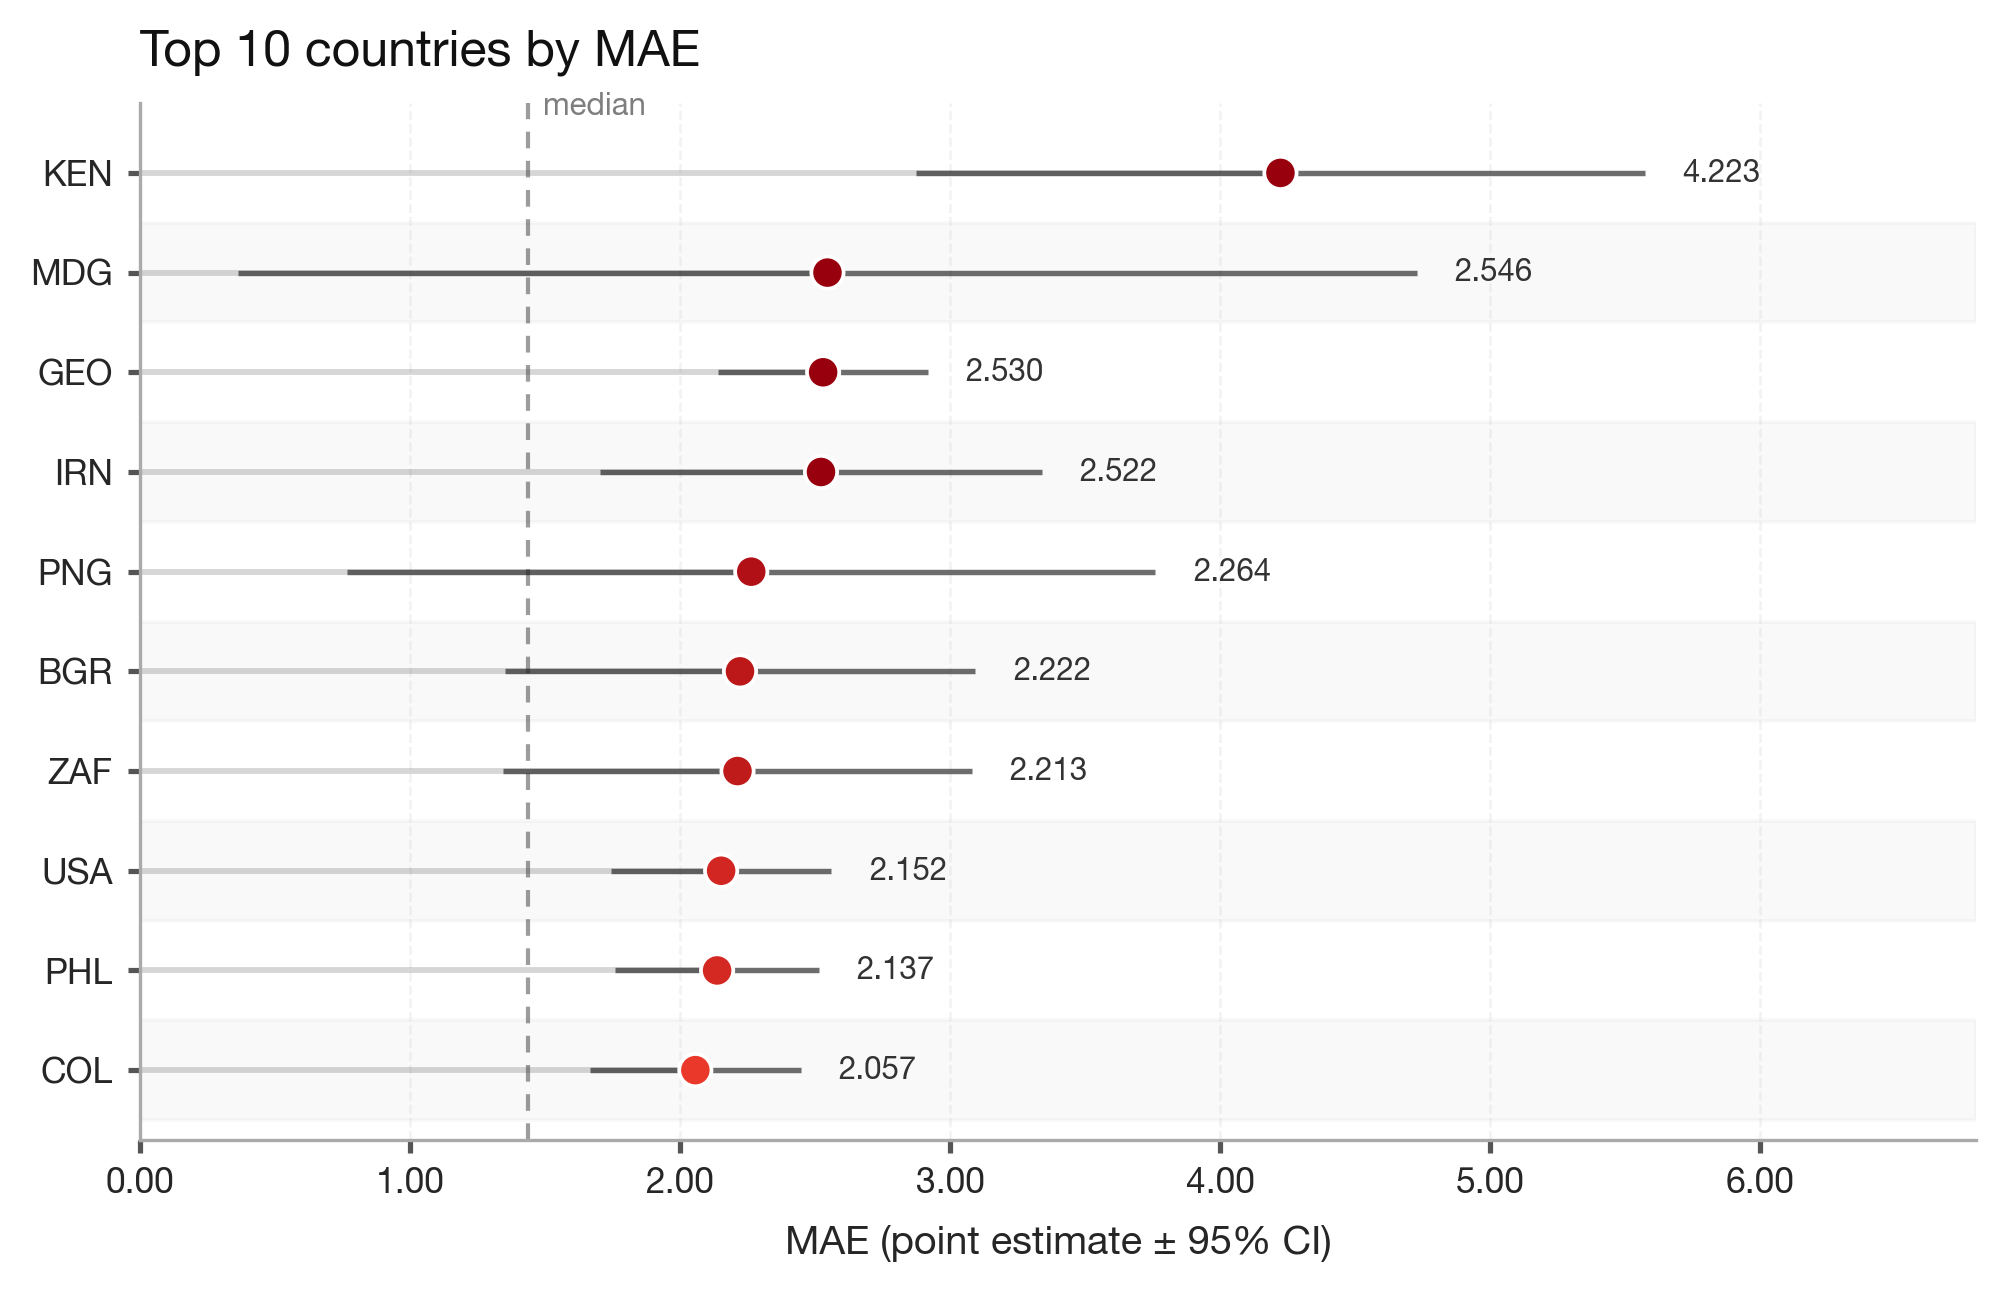

Saved: Per_Country_MAE_Top10_Nature.pdf
Saved: Per_Country_MAE_Top10_Nature.png


In [7]:
# ---------------------------------------------------------------------
# Top-K country MAE lollipop chart
# ---------------------------------------------------------------------
def build_topk_mae_frame(metrics_df, results_df_in, min_samples=3, top_k=TOP_K):
    err_df = results_df_in.copy()
    err_df["abs_error"] = (err_df["y_true"] - err_df["y_pred_B"]).abs()

    mae_stats = (
        err_df.groupby("iso3", observed=True)["abs_error"]
        .agg(MAE="mean", n="size", sd="std")
        .reset_index()
    )
    mae_stats["sd"] = mae_stats["sd"].fillna(0.0)
    mae_stats["mae_se"] = mae_stats["sd"] / np.sqrt(mae_stats["n"].clip(lower=1))
    mae_stats["ci95"] = 1.96 * mae_stats["mae_se"]

    plot_df = (
        metrics_df[["iso3", "R2"]]
        .merge(mae_stats[["iso3", "MAE", "n", "ci95"]], on="iso3", how="right")
        .dropna(subset=["iso3", "MAE", "n"])
    )
    plot_df = plot_df[plot_df["n"] >= min_samples].copy()

    top_df = (
        plot_df.sort_values("MAE", ascending=False)
        .head(top_k)
        .sort_values("MAE", ascending=True)
        .reset_index(drop=True)
    )
    return plot_df, top_df

def plot_topk_mae_lollipop(plot_df, top_df, top_k=TOP_K, out_pdf="Per_Country_MAE_Top10_Nature.pdf", out_png="Per_Country_MAE_Top10_Nature.png"):
    median_mae = float(plot_df["MAE"].median())
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "nature_red",
        ["#fff5f0", "#fee0d2", "#fcbba1", "#fc9272", "#ef3b2c", "#99000d"],
    )
    vmin = float(plot_df["MAE"].quantile(0.05))
    vmax = float(plot_df["MAE"].quantile(0.95))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig = plt.figure(figsize=(8.5, 4.8), dpi=300)
    ax = fig.add_axes([0.11, 0.13, 0.72, 0.72])
    y_pos = np.arange(len(top_df))

    ax.hlines(
        y=y_pos,
        xmin=0,
        xmax=top_df["MAE"],
        colors=(0.27, 0.27, 0.27, 0.22),
        linewidths=1.4,
        zorder=1,
    )
    ax.errorbar(
        x=top_df["MAE"],
        y=y_pos,
        xerr=top_df["ci95"],
        fmt="none",
        ecolor=(0.12, 0.12, 0.12, 0.65),
        elinewidth=1.3,
        capsize=0,
        zorder=2,
    )
    ax.scatter(
        top_df["MAE"],
        y_pos,
        c=top_df["MAE"],
        cmap=cmap,
        norm=norm,
        s=60,
        zorder=3,
        edgecolors="white",
        linewidths=0.9,
    )

    x_max = float((top_df["MAE"] + top_df["ci95"]).max())
    label_pad = x_max * 0.025
    for i, row in top_df.iterrows():
        ax.text(
            row["MAE"] + row["ci95"] + label_pad,
            i,
            f'{row["MAE"]:.3f}',
            va="center",
            ha="left",
            fontsize=7.5,
            color="#333333",
        )

    ax.axvline(median_mae, color=(0.08, 0.08, 0.08, 0.42), linewidth=1.0, linestyle=(0, (4, 3)), zorder=0)
    ax.text(
        median_mae + x_max * 0.01,
        y_pos[-1] + 0.52,
        "median",
        fontsize=7.5,
        fontstyle="italic",
        color=(0.08, 0.08, 0.08, 0.55),
        va="bottom",
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_df["iso3"], fontsize=9)
    ax.set_ylim(-0.7, len(top_df) - 0.3)
    ax.set_xlim(0, x_max * 1.22)
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="y", length=0)
    style_matplotlib_axes(
        ax,
        title=f"Top {top_k} countries by MAE",
        xlabel="MAE (point estimate ± 95% CI)",
        ylabel="",
        grid_axis="x",
    )

    for i in range(len(top_df)):
        if i % 2 == 0:
            ax.axhspan(i - 0.5, i + 0.5, color=(0, 0, 0, 0.025), zorder=0)

    fig.savefig(out_pdf, bbox_inches="tight", dpi=300)
    fig.savefig(out_png, bbox_inches="tight", dpi=300)
    plt.show()
    print(f"Saved: {out_pdf}")
    print(f"Saved: {out_png}")

plot_df, top10_df = build_topk_mae_frame(metrics, results_df, min_samples=3, top_k=TOP_K)
plot_topk_mae_lollipop(plot_df, top10_df, top_k=TOP_K)